In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_date, col

spark = SparkSession.builder.appName("DataProcessing").getOrCreate()

data = [
    (1, 'productA', 100.0, '2023-01-01'),
    (2, 'productB', 200.0, '2023-01-02'),
    (1, 'productA', 100.0, '2023-01-01'), # Duplicate
    (3, 'productC', None, '2023-01-03'), # Null revenue
    (4, None, 400.0, '2023-01-04')      # Null product
]
columns = ['order_id', 'product', 'revenue', 'order_date']
df_bronze = spark.createDataFrame(data, columns)

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)

df_silver.show()

+--------+--------+-------+----------+
|order_id| product|revenue|order_date|
+--------+--------+-------+----------+
|       2|productB|  200.0|2023-01-02|
|       1|productA|  100.0|2023-01-01|
+--------+--------+-------+----------+



In [ ]:
from pyspark.sql import functions as F

montly_tread = df_silver \
    .withColumn('order_month', F.date_trunc('month', F.col('order_date'))) \
    .groupBy('order_month') \
    .agg(F.sum('revenue').alias('total_revenue')) \
    .orderBy('order_month')

montly_tread.show()

+-------------------+-------------+
|        order_month|total_revenue|
+-------------------+-------------+
|2023-01-01 00:00:00|        300.0|
+-------------------+-------------+



In [ ]:
color_revenue = df_silver \
    .groupBy('product') \
    .agg(F.sum('revenue').alias('total_revenue')) \
    .orderBy('total_revenue', ascending=False)

color_revenue.show()


+--------+-------------+
| product|total_revenue|
+--------+-------------+
|productB|        200.0|
|productA|        100.0|
+--------+-------------+



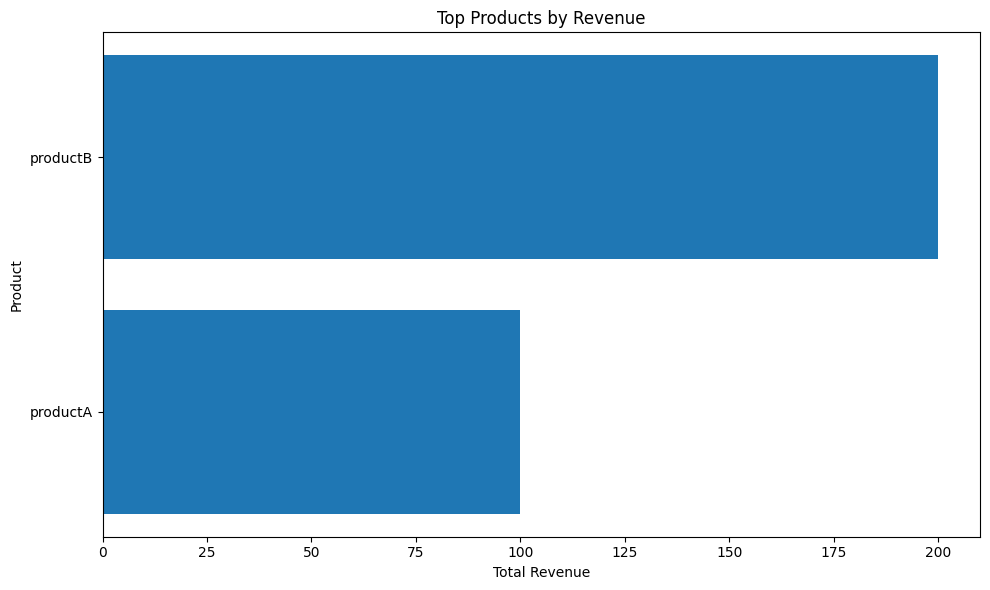

In [ ]:
import matplotlib.pyplot as plt

pandas_color_revenue = color_revenue.toPandas()

pandas_color_revenue = pandas_color_revenue.sort_values(by='total_revenue', ascending=True)

fig, ax2 = plt.subplots(figsize=(10, 6))

ax2.barh(pandas_color_revenue['product'], pandas_color_revenue['total_revenue'])
ax2.set_title('Top Products by Revenue')
ax2.set_xlabel('Total Revenue')
ax2.set_ylabel('Product')

plt.tight_layout()
plt.show()